In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

woe_df = pd.read_csv('D:\BankLoanRisk-Intelligence\Dataset\loans_woe_transformed.csv')
meta = pd.read_csv('D:\BankLoanRisk-Intelligence\Dataset\loans_model_ready.csv', usecols=['id', 'grade', 'vintage_month'])
data = woe_df.merge(meta, on='id', how='left')

FEATURE_COLS = [c for c in woe_df.columns if c.endswith('_woe')]
print('Features used:', FEATURE_COLS)
print(data.shape)

Features used: ['bureau_score_woe', 'dti_woe', 'home_ownership_woe', 'loan_amnt_woe', 'revol_util_woe', 'monthly_income_woe', 'inq_last_6mths_woe', 'purpose_woe']
(150000, 12)


In [4]:
vintages_sorted = sorted(data['vintage_month'].unique())
cutoff_idx = int(len(vintages_sorted) * 0.7)
train_vintages = set(vintages_sorted[:cutoff_idx])
test_vintages = set(vintages_sorted[cutoff_idx:])

train = data[data['vintage_month'].isin(train_vintages)].copy()
test = data[data['vintage_month'].isin(test_vintages)].copy()

print(f"Train: {len(train):,} loans, vintages {min(train_vintages)}–{max(train_vintages)}")
print(f"Test:  {len(test):,} loans, vintages {min(test_vintages)}–{max(test_vintages)}")
print(f"Train default rate: {train['defaulted'].mean():.2%}  |  Test default rate: {test['defaulted'].mean():.2%}")

Train: 134,913 loans, vintages 2015-01–2017-09
Test:  15,087 loans, vintages 2017-10–2018-12
Train default rate: 21.88%  |  Test default rate: 18.57%


In [5]:
X_train, y_train = train[FEATURE_COLS], train['defaulted']
X_test, y_test = test[FEATURE_COLS], test['defaulted']

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

coef_table = pd.DataFrame({'feature': FEATURE_COLS, 'coefficient': model.coef_[0]}).sort_values(
    'coefficient', key=abs, ascending=False)
coef_table

,feature,coefficient
3,loan_amnt_woe,-1.731713
5,monthly_income_woe,-1.138173
0,bureau_score_woe,-1.021804
6,inq_last_6mths_woe,-0.924212
7,purpose_woe,-0.830469
1,dti_woe,-0.808941
2,home_ownership_woe,-0.796364
4,revol_util_woe,0.144822


In [6]:
test_probs_default = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, test_probs_default)
gini = 2 * auc - 1
fpr, tpr, thresholds = roc_curve(y_test, test_probs_default)
ks = np.max(tpr - fpr) * 100

print(f"AUC:  {auc:.4f}")
print(f"Gini: {gini:.4f}")
print(f"KS:   {ks:.2f}")
print("\nRule-of-thumb bands (from Documentation/methodology_notes.md):")
print("KS  < 20 Poor | 20-40 Acceptable | 40-60 Good | 60-75 Very strong | >75 check leakage")

AUC:  0.6713
Gini: 0.3425
KS:   24.06

Rule-of-thumb bands (from Documentation/methodology_notes.md):
KS  < 20 Poor | 20-40 Acceptable | 40-60 Good | 60-75 Very strong | >75 check leakage


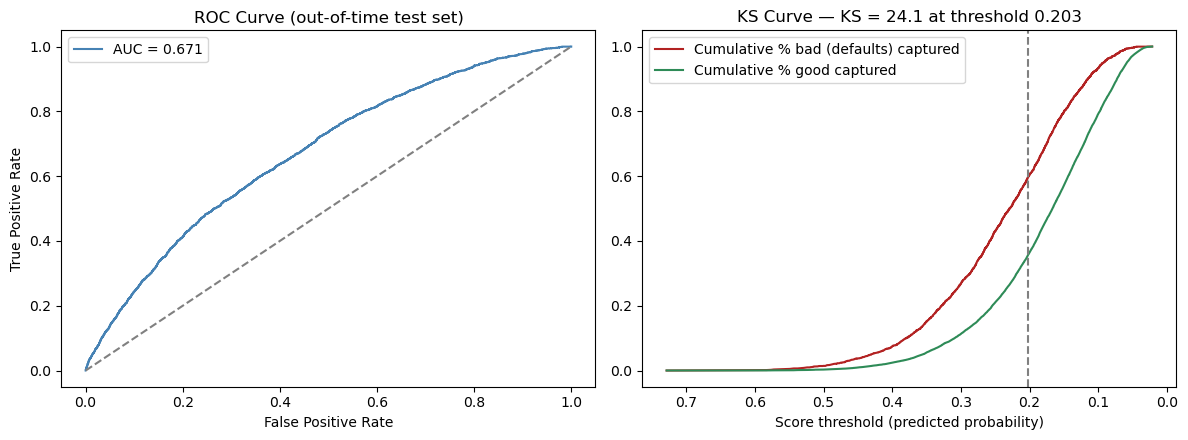

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (out-of-time test set)')
axes[0].legend()

ks_idx = np.argmax(tpr - fpr)
axes[1].plot(thresholds, tpr, label='Cumulative % bad (defaults) captured', color='firebrick')
axes[1].plot(thresholds, fpr, label='Cumulative % good captured', color='seagreen')
axes[1].axvline(thresholds[ks_idx], linestyle='--', color='gray')
axes[1].set_xlabel('Score threshold (predicted probability)')
axes[1].set_title(f'KS Curve — KS = {ks:.1f} at threshold {thresholds[ks_idx]:.3f}')
axes[1].invert_xaxis()
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
BASE_SCORE = 600
BASE_ODDS = 50       # at the base score, odds of 'good' to 'bad' are 50:1
PDO = 20             # every 20 points doubles the odds

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

def prob_default_to_score(p_default, floor=300, ceiling=850):
    p_default = np.clip(p_default, 1e-6, 1 - 1e-6)
    odds_good = (1 - p_default) / p_default
    score = offset + factor * np.log(odds_good)
    return np.clip(score, floor, ceiling).round().astype(int)

test = test.copy()
test['model_score'] = prob_default_to_score(test_probs_default)

# Risk grade cutoffs: use score deciles from the TRAIN population so grade thresholds
# don't shift every time you re-run on new data — deployable, not just descriptive
train_probs_default = model.predict_proba(X_train)[:, 1]
train_scores = prob_default_to_score(train_probs_default)
grade_edges = np.percentile(train_scores, [0, 10, 25, 45, 65, 80, 92, 100])
grade_labels = ['G', 'F', 'E', 'D', 'C', 'B', 'A']

test['model_risk_grade'] = pd.cut(test['model_score'], bins=grade_edges, labels=grade_labels, include_lowest=True)

grade_check = test.groupby('model_risk_grade', observed=True).agg(
    loans=('id', 'count'), avg_score=('model_score', 'mean'), default_rate=('defaulted', 'mean')
).sort_values('avg_score')
grade_check

,loans,avg_score,default_rate
model_risk_grade,,,
G,1024,497.261719,0.387695
F,1682,509.805589,0.303805
E,2352,519.148384,0.241497
D,3133,528.522183,0.187041
C,2452,537.797716,0.147227
B,2360,547.990254,0.111017
A,2084,564.699136,0.056142


In [9]:
def calculate_psi(expected, actual, n_bins=10):
    """PSI between two score distributions. 'expected' = baseline (train), 'actual' = new (test)."""
    edges = np.percentile(expected, np.linspace(0, 100, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    expected_dist = np.histogram(expected, bins=edges)[0] / len(expected)
    actual_dist = np.histogram(actual, bins=edges)[0] / len(actual)
    expected_dist = np.clip(expected_dist, 1e-4, None)
    actual_dist = np.clip(actual_dist, 1e-4, None)
    psi = np.sum((actual_dist - expected_dist) * np.log(actual_dist / expected_dist))
    return psi

psi_value = calculate_psi(train_scores, test['model_score'].values)
print(f"PSI (train vs. out-of-time test): {psi_value:.4f}")
print("< 0.1 no significant shift | 0.1-0.25 moderate shift | > 0.25 major shift, retrain")

PSI (train vs. out-of-time test): 0.0869
< 0.1 no significant shift | 0.1-0.25 moderate shift | > 0.25 major shift, retrain


In [10]:
comparison = pd.crosstab(test['grade'], test['model_risk_grade'])
comparison

model_risk_grade,G,F,E,D,C,B,A
grade,,,,,,,
A,9,60,133,323,518,851,1338
B,151,304,583,956,886,846,526
C,257,549,826,1054,651,444,151
D,390,494,567,588,299,168,52
E,142,196,198,170,89,45,14
F,54,54,34,33,6,4,3
G,21,25,11,9,3,2,0


In [11]:
side_by_side = pd.DataFrame({
    'lc_grade_default_rate': test.groupby('grade')['defaulted'].mean(),
    'lc_grade_loans': test.groupby('grade')['id'].count(),
}).join(pd.DataFrame({
    'model_grade_default_rate': test.groupby('model_risk_grade', observed=True)['defaulted'].mean(),
    'model_grade_loans': test.groupby('model_risk_grade', observed=True)['id'].count(),
}), how='outer')
side_by_side

,lc_grade_default_rate,lc_grade_loans,model_grade_default_rate,model_grade_loans
A,0.055693,3232,0.056142,2084
B,0.131468,4252,0.111017,2360
C,0.224313,3932,0.147227,2452
D,0.304144,2558,0.187041,3133
E,0.340749,854,0.241497,2352
F,0.414894,188,0.303805,1682
G,0.478873,71,0.387695,1024


In [15]:
all_probs_default = model.predict_proba(data[FEATURE_COLS])[:, 1]
data['model_score'] = prob_default_to_score(all_probs_default)
data['model_risk_grade'] = pd.cut(data['model_score'], bins=grade_edges, labels=grade_labels, include_lowest=True)

output_cols = ['id', 'model_score', 'model_risk_grade']
data[output_cols].to_csv(r"D:\BankLoanRisk-Intelligence\Dataset\loans_scored.csv", index=False)

eval_summary = {
    'auc': round(float(auc), 4),
    'gini': round(float(gini), 4),
    'ks': round(float(ks), 2),
    'psi_train_vs_test': round(float(psi_value), 4),
    'train_vintages': [min(train_vintages), max(train_vintages)],
    'test_vintages': [min(test_vintages), max(test_vintages)],
    'train_default_rate': round(float(train['defaulted'].mean()), 4),
    'test_default_rate': round(float(test['defaulted'].mean()), 4),
}

import json
with open(r"D:\BankLoanRisk-Intelligence\Documentation\model_evaluation_summary.json", 'w') as f:
    json.dump(eval_summary, f, indent=2)

print(r"Saved D:\BankLoanRisk-Intelligence\Dataset\loans_scored.csv —", data[output_cols].shape)
print(r"Saved D:\BankLoanRisk-Intelligence\Documentation\model_evaluation_summary.json")
print(eval_summary)

Saved D:\BankLoanRisk-Intelligence\Dataset\loans_scored.csv — (150000, 3)
Saved D:\BankLoanRisk-Intelligence\Documentation\model_evaluation_summary.json
{'auc': 0.6713, 'gini': 0.3425, 'ks': 24.06, 'psi_train_vs_test': 0.0869, 'train_vintages': ['2015-01', '2017-09'], 'test_vintages': ['2017-10', '2018-12'], 'train_default_rate': 0.2188, 'test_default_rate': 0.1857}
